# 01 — Exploración inicial (Lending Club)

**Proyecto final de Machine Learning — Entrega previa**

Predicción de incumplimiento de préstamos usando solo información disponible en
el momento de la decisión crediticia.

Este notebook cubre los requisitos obligatorios de la exploración inicial:
carga, tipos, faltantes, distribución del target, ≥5 visualizaciones,
outliers, discusión de sesgos/leakage/limitaciones y un **baseline simple
ejecutado**. El código pesado vive en `src/` para ser reutilizable.

In [1]:
import sys, os, json
from pathlib import Path

# --- Localizar la raíz del repo (funciona desde notebooks/ o desde la raíz) ---
ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.data import load_dataset, load_raw

sns.set_theme(style="whitegrid")
np.random.seed(config.SEED)
FIG = config.FIGURES_DIR
pd.set_option("display.max_columns", 60)
print("Raíz del proyecto:", ROOT)
print("Semilla:", config.SEED)

Raíz del proyecto: /home/claude/proyecto-final
Semilla: 42


## Configuración de la muestra

Coloca el archivo de Lending Club en `data/` (ver `data/README.md`). El archivo
completo tiene ~2.26M filas; para la exploración inicial puedes trabajar con una
muestra representativa ajustando `SAMPLE_ROWS`. Deja `SAMPLE_ROWS = None` para
usar todo el archivo.

In [2]:
# Ruta al dataset (None = usa data/<RAW_FILENAME> de config.py)
DATA_PATH = None
# Muestra aleatoria reproducible del archivo completo. Con ~2.26M filas y las
# múltiples copias del pipeline, cargar todo agota la RAM; una muestra del 40%
# (~500k préstamos con resultado observado) es representativa y suficiente para
# la exploración y el baseline. Decisión de muestreo documentada (rúbrica).
SAMPLE_FRAC = 0.4       # None = todas las filas

# El archivo completo tiene ~150 columnas y ~2.26M filas (1.6 GB). Para no
# agotar memoria, leemos una muestra CON TODAS las columnas solo para inspeccionar
# estructura/tipos, y luego el dataset de modelado con las columnas necesarias.
from src.data import _resolve_path, RAW_USECOLS
raw_sample = load_raw(DATA_PATH, nrows=100_000, usecols=None)
n_cols = raw_sample.shape[1]
print(f"El archivo tiene {n_cols} columnas.")

El archivo tiene 151 columnas.


## 1. Número de filas, columnas y tipos de datos

In [3]:
# Nº total de filas del archivo (conteo por streaming, sin cargarlo entero)
_p = _resolve_path(DATA_PATH)
total_rows = sum(1 for _ in open(_p)) - 1
print(f"Archivo crudo: {total_rows:,} filas x {n_cols} columnas")
print()
print("Tipos de datos (resumen sobre muestra de 100k filas):")
print(raw_sample.dtypes.value_counts())
print()
print("Ejemplos de columnas y tipos:")
display(raw_sample.dtypes.head(20).to_frame("dtype"))

Archivo crudo: 2,260,701 filas x 151 columnas

Tipos de datos (resumen sobre muestra de 100k filas):
float64    114
str         36
int64        1
Name: count, dtype: int64

Ejemplos de columnas y tipos:


,dtype
id,int64
member_id,float64
loan_amnt,float64
funded_amnt,float64
funded_amnt_inv,float64
term,str
int_rate,float64
installment,float64
grade,str
sub_grade,str


## 2. Variable objetivo

Construimos `target_default` a partir de `loan_status` y descartamos los
préstamos cuyo resultado aún no es observable (Current, In Grace Period, etc.).

Muestra de trabajo (frac=0.4), tras filtrar a préstamos con resultado observado: 547,578 filas
Buenos (0): 431,376  |  Malos/default (1): 116,202
Tasa de default: 21.221%


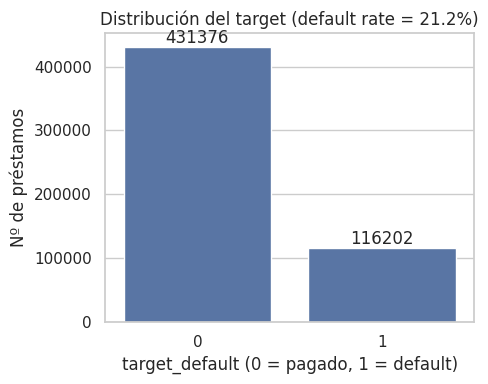

In [4]:
df = load_dataset(DATA_PATH, frac=SAMPLE_FRAC)
print(f"Muestra de trabajo (frac={SAMPLE_FRAC}), tras filtrar a préstamos con "
      f"resultado observado: {df.shape[0]:,} filas")

vc = df[config.TARGET_BINARY].value_counts().sort_index()
rate = df[config.TARGET_BINARY].mean()
print(f"Buenos (0): {vc.get(0,0):,}  |  Malos/default (1): {vc.get(1,0):,}")
print(f"Tasa de default: {rate:.3%}")

fig, ax = plt.subplots(figsize=(5,4))
sns.countplot(x=df[config.TARGET_BINARY], ax=ax)
ax.set_title(f"Distribución del target (default rate = {rate:.1%})")
ax.set_xlabel("target_default (0 = pagado, 1 = default)")
ax.set_ylabel("Nº de préstamos")
for c in ax.containers: ax.bar_label(c, fmt="%d")
fig.tight_layout(); fig.savefig(FIG/"01_target_distribution.png", dpi=120); plt.show()

**Lectura:** el problema está **desbalanceado** (la clase de interés,
default, es minoritaria). Esto justifica no usar accuracy como métrica principal.
El baseline se deja **sin balanceo** (proposal §11); el manejo del desbalance
(class_weight / resampling) se aborda en la fase de modelado.

## 3. Porcentaje de valores faltantes por variable

113 de 151 columnas tienen faltantes.


,% faltante
member_id,100.00
orig_projected_additional_accrued_interest,99.62
hardship_reason,99.52
hardship_payoff_balance_amount,99.52
hardship_last_payment_amount,99.52
payment_plan_start_date,99.52
hardship_type,99.52
hardship_status,99.52
hardship_start_date,99.52
deferral_term,99.52


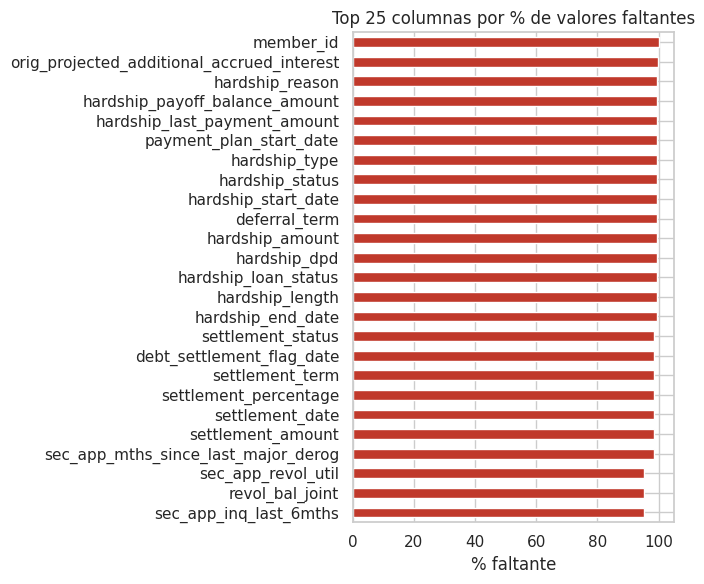

In [5]:
# Faltantes sobre TODAS las columnas del archivo completo (lectura en chunks)
from src.data import stream_missingness
miss = stream_missingness(DATA_PATH)
miss_nonzero = miss[miss > 0]
print(f"{len(miss_nonzero)} de {n_cols} columnas tienen faltantes.")
display(miss_nonzero.head(25).to_frame("% faltante").round(2))

fig, ax = plt.subplots(figsize=(7,6))
miss_nonzero.head(25).iloc[::-1].plot.barh(ax=ax, color="#c0392b")
ax.set_title("Top 25 columnas por % de valores faltantes")
ax.set_xlabel("% faltante")
fig.tight_layout(); fig.savefig(FIG/"02_missingness.png", dpi=120); plt.show()

**Nota sobre faltantes no aleatorios:** columnas como
`mths_since_last_delinq` o `mths_since_last_record` faltan precisamente cuando el
solicitante *no* tuvo ese evento negativo. La ausencia es informativa, así que
en la entrega final evaluaremos un indicador de faltante además de imputar.

## 4. Visualizaciones relevantes

Cinco vistas centradas en la relación de las variables de originación con el
riesgo de default.

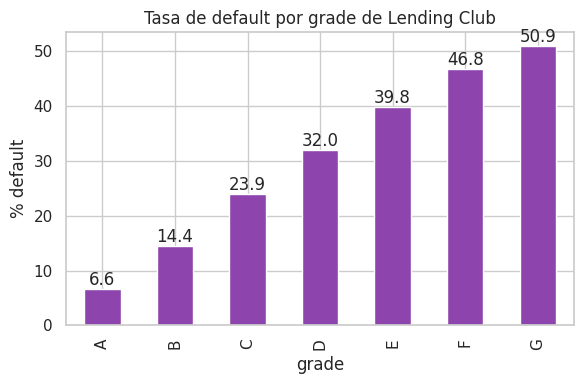

In [6]:
# 4.1 Tasa de default por grado de riesgo (grade)
if "grade" in df.columns:
    g = (df.groupby("grade")[config.TARGET_BINARY].mean().sort_index()*100)
    fig, ax = plt.subplots(figsize=(6,4))
    g.plot.bar(ax=ax, color="#8e44ad")
    ax.set_title("Tasa de default por grade de Lending Club")
    ax.set_ylabel("% default"); ax.set_xlabel("grade")
    for c in ax.containers: ax.bar_label(c, fmt="%.1f")
    fig.tight_layout(); fig.savefig(FIG/"03_default_by_grade.png", dpi=120); plt.show()

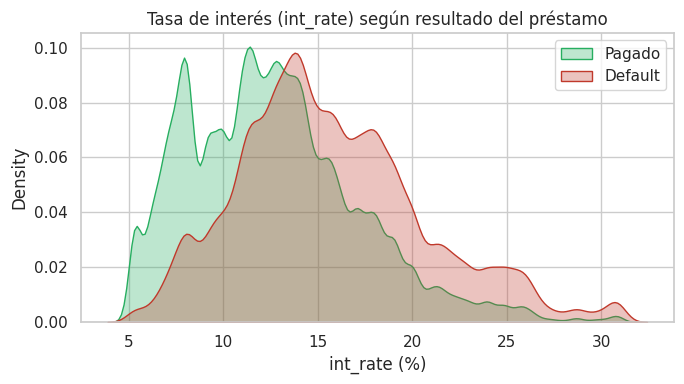

In [7]:
# 4.2 Distribución de int_rate segun resultado
if "int_rate" in df.columns:
    fig, ax = plt.subplots(figsize=(7,4))
    for k, lbl, col in [(0,"Pagado","#27ae60"),(1,"Default","#c0392b")]:
        sub = df.loc[df[config.TARGET_BINARY]==k, "int_rate"].dropna()
        sns.kdeplot(sub, ax=ax, label=lbl, fill=True, alpha=.3, color=col)
    ax.set_title("Tasa de interés (int_rate) según resultado del préstamo")
    ax.set_xlabel("int_rate (%)"); ax.legend()
    fig.tight_layout(); fig.savefig(FIG/"04_intrate_by_target.png", dpi=120); plt.show()

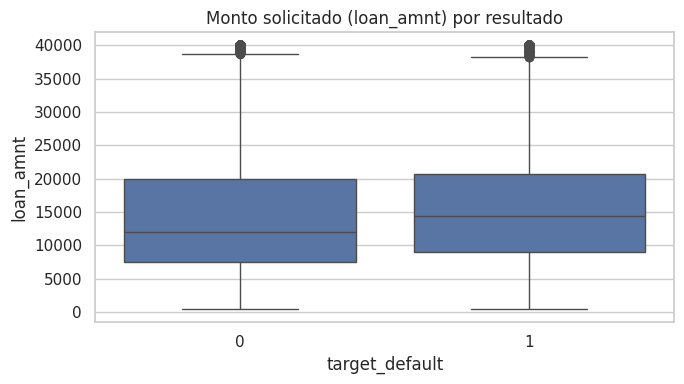

In [8]:
# 4.3 Distribución del monto solicitado por resultado
if "loan_amnt" in df.columns:
    fig, ax = plt.subplots(figsize=(7,4))
    sns.boxplot(data=df, x=config.TARGET_BINARY, y="loan_amnt", ax=ax)
    ax.set_title("Monto solicitado (loan_amnt) por resultado")
    ax.set_xlabel("target_default"); ax.set_ylabel("loan_amnt")
    fig.tight_layout(); fig.savefig(FIG/"05_loanamnt_by_target.png", dpi=120); plt.show()

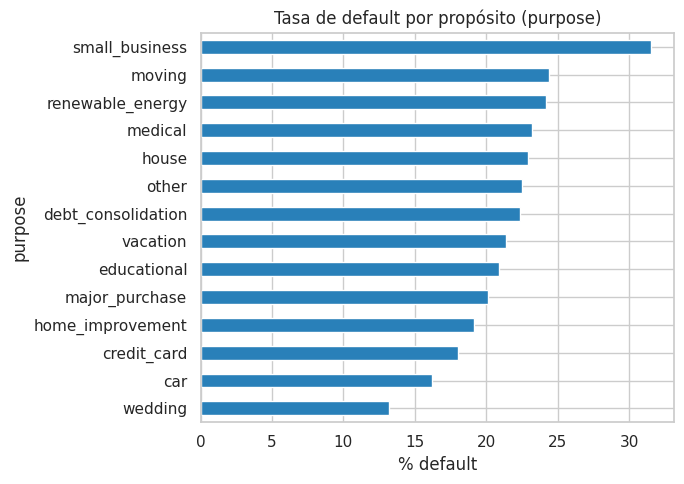

In [9]:
# 4.4 Tasa de default por propósito del préstamo
if "purpose" in df.columns:
    p = (df.groupby("purpose")[config.TARGET_BINARY].mean().sort_values()*100)
    fig, ax = plt.subplots(figsize=(7,5))
    p.plot.barh(ax=ax, color="#2980b9")
    ax.set_title("Tasa de default por propósito (purpose)")
    ax.set_xlabel("% default")
    fig.tight_layout(); fig.savefig(FIG/"06_default_by_purpose.png", dpi=120); plt.show()

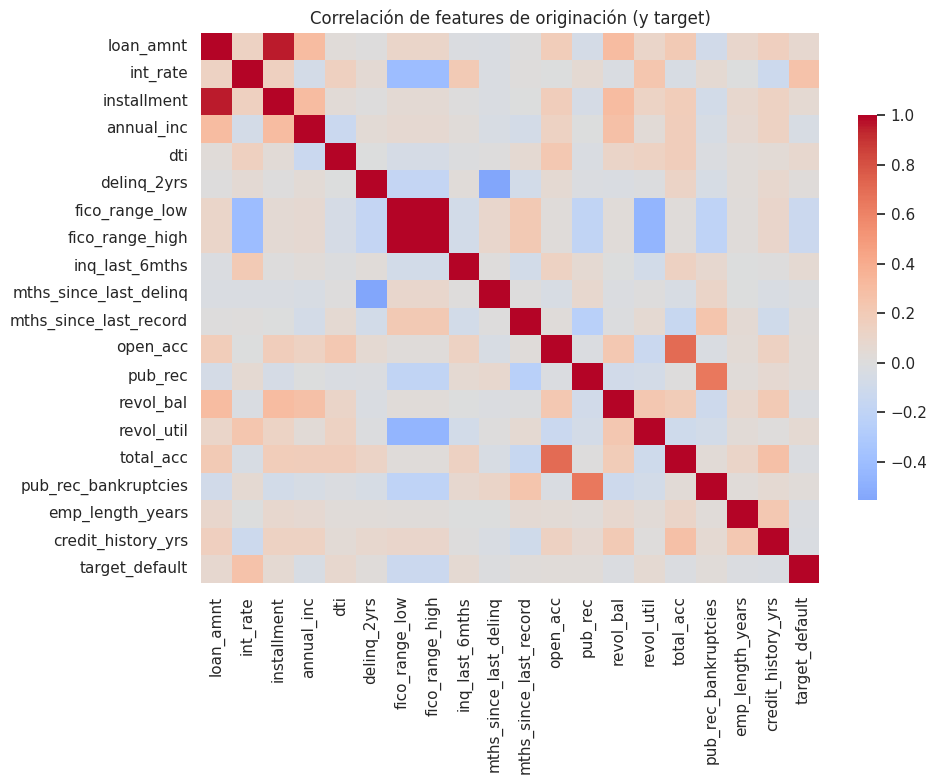

In [10]:
# 4.5 Mapa de correlación entre features numéricas de originación
from src.features import present_features
num, _ = present_features(df)
num = [c for c in num if c in df.columns]
corr = df[num + [config.TARGET_BINARY]].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, cbar_kws={"shrink":.7})
ax.set_title("Correlación de features de originación (y target)")
fig.tight_layout(); fig.savefig(FIG/"07_corr_heatmap.png", dpi=120); plt.show()

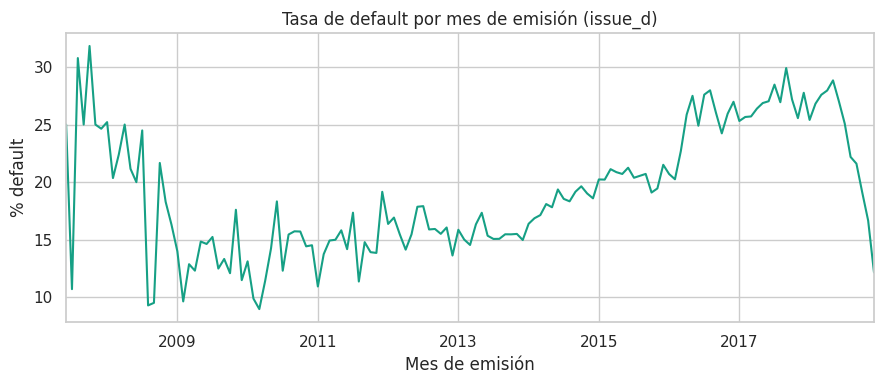

In [11]:
# 4.6 Deriva temporal: tasa de default por mes de emisión
iss = pd.to_datetime(df["issue_d"], format="%b-%Y", errors="coerce")
ts = (df.assign(_m=iss.dt.to_period("M").dt.to_timestamp())
        .groupby("_m")[config.TARGET_BINARY].mean()*100)
fig, ax = plt.subplots(figsize=(9,4))
ts.plot(ax=ax, color="#16a085")
ax.set_title("Tasa de default por mes de emisión (issue_d)")
ax.set_ylabel("% default"); ax.set_xlabel("Mes de emisión")
fig.tight_layout(); fig.savefig(FIG/"08_default_over_time.png", dpi=120); plt.show()

**Lectura:** el riesgo crece monótonamente con `grade`/`int_rate` (señal
esperada y disponible en la decisión) y **varía en el tiempo**, lo que motiva la
partición temporal (out-of-time) en lugar de aleatoria.

## 5. Identificación de outliers / registros sospechosos

,annual_inc,dti,revol_util,loan_amnt
count,547575.00,547417.00,547199.00,547578.00
mean,76101.85,18.28,51.74,14430.75
std,69410.65,11.07,24.53,8730.28
min,0.00,0.00,0.00,500.00
1%,18000.00,1.75,1.00,1500.00
25%,45500.00,11.77,33.30,8000.00
50%,65000.00,17.60,52.10,12000.00
75%,90000.00,24.05,70.70,20000.00
99%,250000.00,38.51,98.20,35000.00
max,9573072.00,999.00,182.80,40000.00


Ingresos anuales > 1,000,000: 124
DTI > 60 (posible error): 771


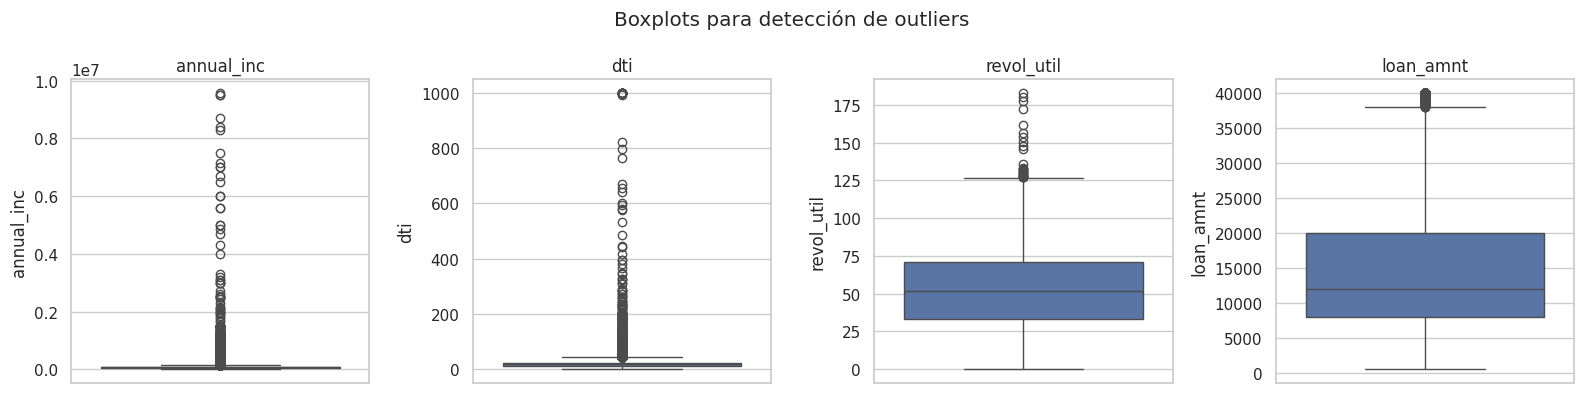

In [12]:
cols = [c for c in ["annual_inc","dti","revol_util","loan_amnt"] if c in df.columns]
display(df[cols].describe(percentiles=[.01,.25,.5,.75,.99]).round(2))

# Ejemplos de valores sospechosos
if "annual_inc" in df.columns:
    print("Ingresos anuales > 1,000,000:", int((df['annual_inc']>1_000_000).sum()))
if "dti" in df.columns:
    print("DTI > 60 (posible error):", int((df['dti']>60).sum()))

fig, axes = plt.subplots(1, len(cols), figsize=(4*len(cols),4))
for ax, c in zip(np.atleast_1d(axes), cols):
    sns.boxplot(y=df[c], ax=ax); ax.set_title(c)
fig.suptitle("Boxplots para detección de outliers")
fig.tight_layout(); fig.savefig(FIG/"09_outliers.png", dpi=120); plt.show()

**Lectura:** `annual_inc` tiene colas extremas (ingresos autodeclarados) y
`dti` presenta valores imposibles en algunos registros. En la entrega final se
recortarán/winsorizarán con umbrales justificados, ajustados **solo con train**.

## 6. Discusión inicial: sesgos, leakage y limitaciones

**Leakage (riesgo principal).** El dataset incluye decenas de columnas
generadas *después* de otorgar el crédito: pagos (`total_pymnt`,
`total_rec_prncp`), recuperaciones (`recoveries`), buró actualizado
(`last_fico_range_*`) y acuerdos de liquidación/hardship. Usarlas dispararía las
métricas de forma engañosa. **Control:** `src/features.py` define una *lista
blanca* de variables de originación y una *lista negra* documentada
(`LEAKAGE_COLUMNS`); toda transformación se ajusta solo con train dentro de un
`Pipeline`.

**Sesgos.** (1) *Sesgo de selección/supervivencia*: solo vemos préstamos que LC
ya **aprobó**; el modelo no observa a los rechazados, así que estima riesgo
condicionado a la política de aprobación de LC. (2) *Sesgo temporal*: las
políticas cambiaron entre 2007–2018. (3) *Sesgos sensibles*: variables como
`addr_state` pueden correlacionar con atributos protegidos; se revisará equidad
por segmentos en la entrega final.

**Limitaciones.** Etiquetas definitivas solo para préstamos ya resueltos (los
`Current` se excluyen, lo que puede sesgar hacia plazos más cortos); ingresos y
empleo autodeclarados; faltantes no aleatorios.

## 7. Baseline simple ejecutado

Partición **temporal** por `issue_d` (train = préstamos antiguos, validación =
20% más reciente) y dos referencias: clase mayoritaria y **regresión
logística**. Ejecuta `src/train.py`, que guarda `outputs/metrics.json`.

In [13]:
from src.train import main as train_main
summary = train_main(DATA_PATH, valid_frac=0.2, frac=SAMPLE_FRAC)

m = summary["metrics"]
print(f"n_train={summary['n_train']:,}  n_valid={summary['n_valid']:,}")
print(f"default_rate train={summary['default_rate_train']:.3f} "
      f"valid={summary['default_rate_valid']:.3f}\n")
tbl = pd.DataFrame(m).T[["roc_auc","pr_auc","ks","f1","precision","recall","brier"]]
display(tbl.round(4))

Guardado /home/claude/proyecto-final/outputs/metrics.json
{
  "dummy_prior": {
    "roc_auc": 0.5,
    "pr_auc": 0.265421007359266,
    "ks": 0.019375462543057442,
    "brier": 0.19929958133192058,
    "f1": 0.0,
    "precision": 0.0,
    "recall": 0.0,
    "threshold": 0.5,
    "n": 104630,
    "positive_rate": 0.265421007359266
  },
  "logistic_regression": {
    "roc_auc": 0.6961800040403733,
    "pr_auc": 0.431152874050975,
    "ks": 0.28852303454932576,
    "brier": 0.18131938943788947,
    "f1": 0.11348347470020474,
    "precision": 0.582,
    "recall": 0.06287134060710814,
    "threshold": 0.5,
    "n": 104630,
    "positive_rate": 0.265421007359266
  }
}
n_train=442,948  n_valid=104,630
default_rate train=0.200 valid=0.265



,roc_auc,pr_auc,ks,f1,precision,recall,brier
dummy_prior,0.5000,0.2654,0.0194,0.0000,0.000,0.0000,0.1993
logistic_regression,0.6962,0.4312,0.2885,0.1135,0.582,0.0629,0.1813


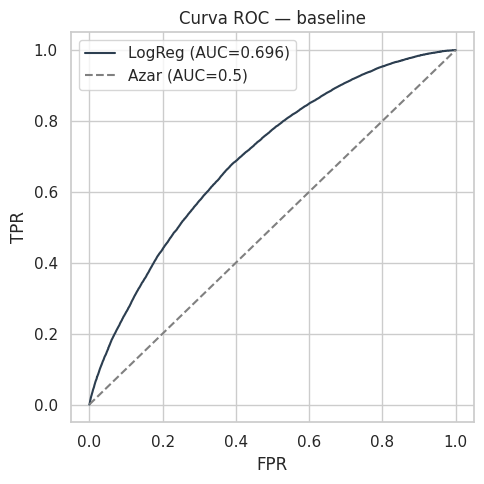

In [14]:
# Curva ROC del baseline logístico vs. referencia trivial
from sklearn.metrics import roc_curve
from src.features import select_features
from src.train import temporal_split, build_baseline_pipeline

tr, va = temporal_split(df, valid_frac=0.2)
Xtr, ytr = select_features(tr), tr[config.TARGET_BINARY]
Xva, yva = select_features(va), va[config.TARGET_BINARY]
pipe = build_baseline_pipeline(tr).fit(Xtr, ytr)
proba = pipe.predict_proba(Xva)[:,1]
fpr, tpr, _ = roc_curve(yva, proba)

fig, ax = plt.subplots(figsize=(5,5))
ax.plot(fpr, tpr, label=f"LogReg (AUC={m['logistic_regression']['roc_auc']:.3f})", color="#2c3e50")
ax.plot([0,1],[0,1],"--",color="gray",label="Azar (AUC=0.5)")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.set_title("Curva ROC — baseline")
ax.legend()
fig.tight_layout(); fig.savefig(FIG/"10_roc_baseline.png", dpi=120); plt.show()

### Lectura inicial del resultado

- La regresión logística supera claramente a la referencia trivial (AUC 0.5),
  confirmando que las variables de originación (sobre todo `grade`/`int_rate`,
  que resumen el scoring interno de LC) tienen poder predictivo **sin leakage**.
- El **KS** y el **PR-AUC** son las métricas a vigilar por el desbalance.
- Este resultado es el piso honesto contra el cual se comparará, en las próximas
  semanas, modelos de árboles y gradient boosting (≥3 familias), con búsqueda de
  hiperparámetros bajo validación temporal.